# RULE-BASED CELL TYPING WITH BANKSY

This notebook provides the workflow from AnnData object to BANKSY domains, rule-based cell typing, annotation of BANKSY domains as B-cell follicles, and spatially informed cell typing.

Your AnnData object should contain marker positivity information) from the compute_positivity_matrix function in annotation.py).

# BANKSY
For this you need a saved .h5ad file containing an anndata object, and Python 12 is required (not a later version of Python). Note that BANKSY only identifies spatial domains and not cell types.

First, load your H5AD file and choose a "base name" to easily keep track of your file and plot naming.

In [20]:
basename = "IHOPE14_MedLN_BottomLeft" #For example


Median distance to closest cell = 6.989277502001307

---- Ran median_dist_to_nearest_neighbour in 1.78 s ----

---- Ran generate_spatial_distance_graph in 2.19 s ----

---- Ran row_normalize in 0.50 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 7.36 s ----

----- Plotting Edge Histograms for m = 0 -----

Edge weights (distances between cells): median = 14.918780110989056, mode = 9.782898607644228

---- Ran plot_edge_histogram in 0.42 s ----


Edge weights (weights between cells): median = 0.05836006462443174, mode = 0.03275129487249155

---- Ran plot_edge_histogram in 0.58 s ----

---- Ran generate_spatial_distance_graph in 3.18 s ----

---- Ran theta_from_spatial_graph in 1.60 s ----

---- Ran row_normalize in 0.50 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 10.12 s ----

----- Plotting Edge Histograms for m = 1 -----

Edge weights (distances between cells): median = 20.806008747474124, mode = 19.34143144099699

---- Ran plot_edge_histogram in 0.27 s ----

---- 

/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/numpy/lib/histograms.py:841: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)


IndexError: index 101 is out of bounds for axis 0 with size 101

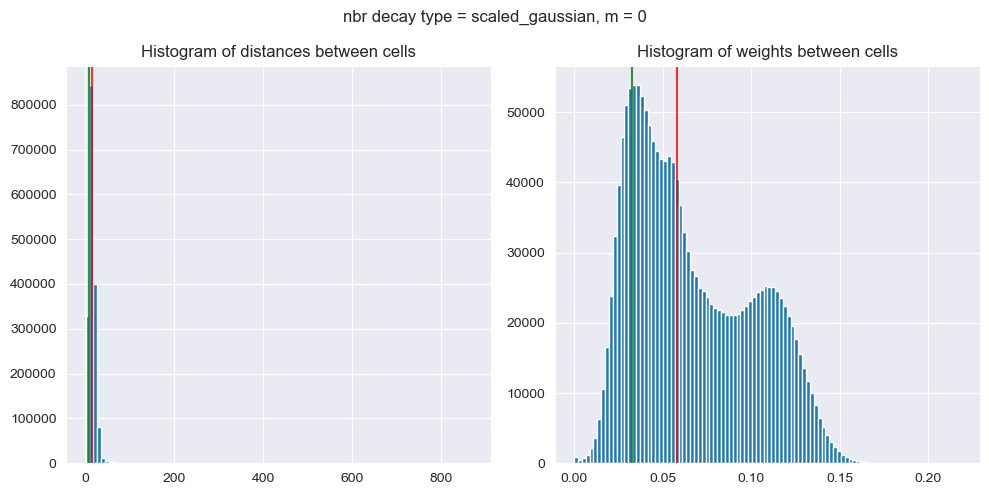

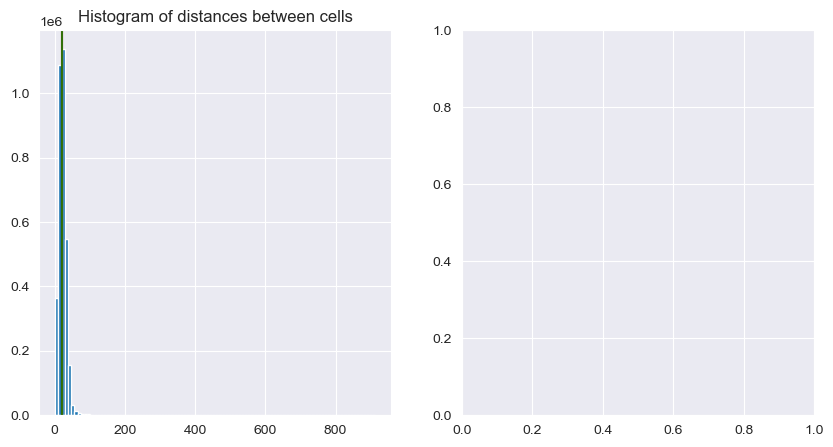

In [21]:
from banksy.initialize_banksy import initialize_banksy
from banksy.run_banksy import run_banksy_multiparam
import scanpy as sc

# Specify path to H5AD file
h5ad_file = f"../data/processed/anndata/{basename}_zscore_GMM_IHOPE_celltypes.h5ad"

# Load your data
adata = sc.read_h5ad(h5ad_file)

# Initialize BANKSY
coord_keys = ('x', 'y', 'spatial')
banksy_dict = initialize_banksy(
    adata,
    coord_keys=coord_keys,
    num_neighbours=15,
    nbr_weight_decay='scaled_gaussian'
)

# Run BANKSY clustering

results_df = run_banksy_multiparam(
    adata,
    banksy_dict,
    lambda_list=[0.2],
    resolutions=[0.5, 1.0]
)


Median distance to closest cell = 6.989277502001307

---- Ran median_dist_to_nearest_neighbour in 1.47 s ----


Median distance to closest cell = 6.989277502001307

---- Ran median_dist_to_nearest_neighbour in 1.09 s ----

---- Ran generate_spatial_distance_graph in 2.02 s ----

---- Ran row_normalize in 0.48 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 6.70 s ----

---- Ran generate_spatial_distance_graph in 4.56 s ----

---- Ran theta_from_spatial_graph in 2.34 s ----

---- Ran row_normalize in 0.85 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 19.42 s ----

----- Plotting Weights Graph -----
Maximum weight: 0.21834196581661036

---- Ran plot_graph_weights in 38.31 s ----

Maximum weight: (0.09076966554277836-0.007179521438041436j)

---- Ran plot_graph_weights in 50.68 s ----

Runtime Jun-23-2026-16-22

38 genes to be analysed:
Gene List:
Index(['arcsinh_cf5.0_CCR6', 'arcsinh_cf5.0_CCR7', 'arcsinh_cf5.0_CD107a',
       'arcsinh_cf5.0_CD11c', 'arcsinh_cf5.0_CD14'

/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/banksy/labels.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  expand_labels(label_list[sort_indices[0]],


,decay,lambda_param,num_pcs,resolution,num_labels,labels,adata,relabeled
scaled_gaussian_pc20_nc0.80_r0.50,scaled_gaussian,0.8,20,0.5,13,"Label object:\nNumber of labels: 13, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 13, number of..."


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_6767/2115476371.py:67: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='banksy_domain', spot_size=30, title='BANKSY Domains')


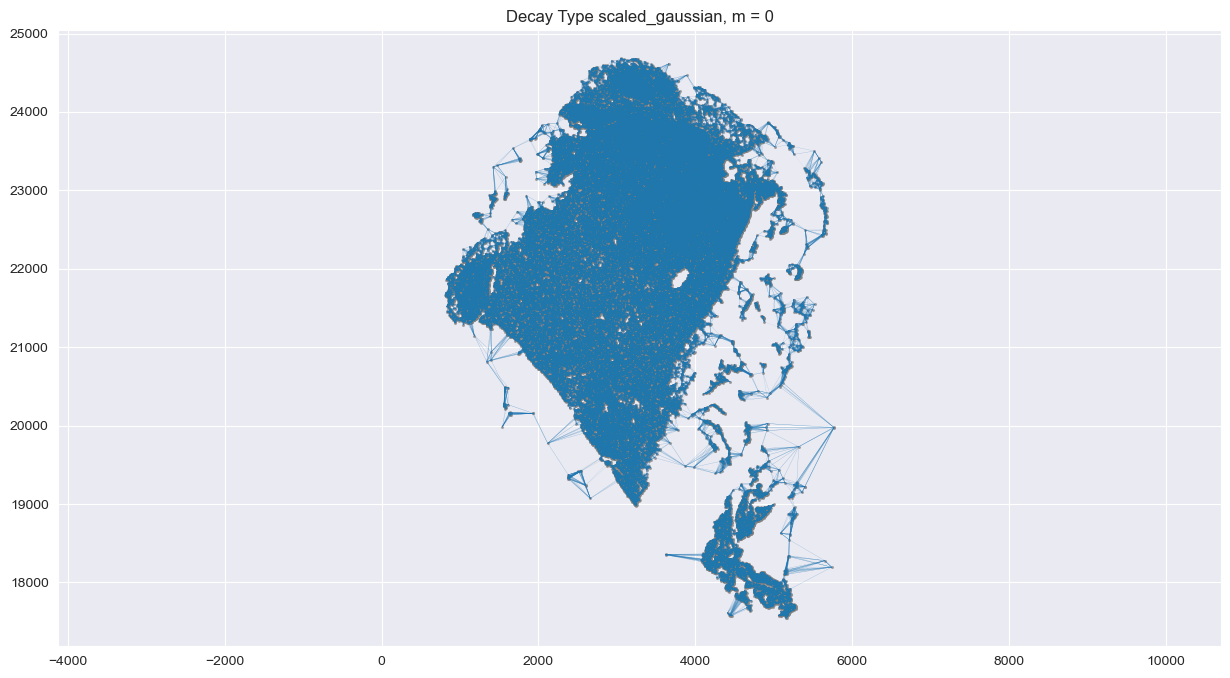

/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/matplotlib/collections.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  renderer.draw_path_collection(


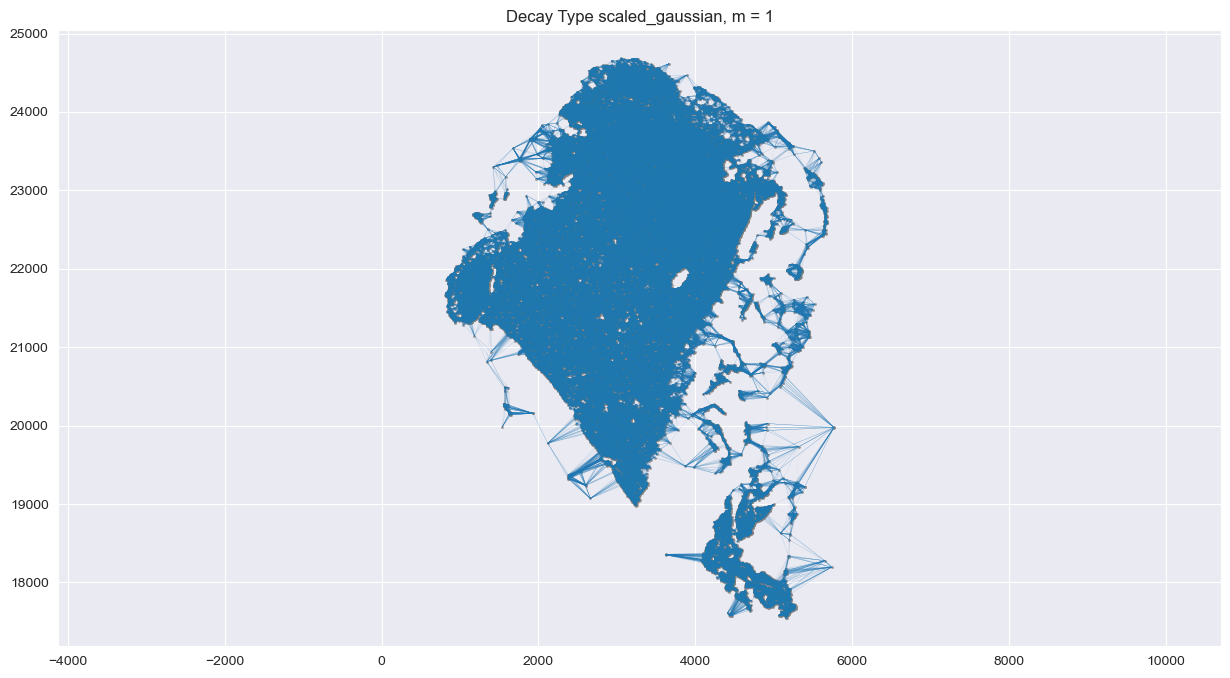

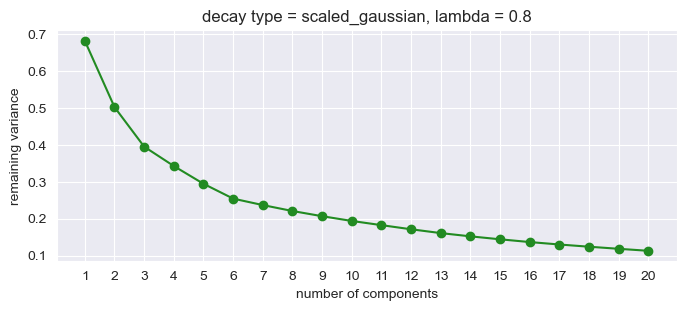

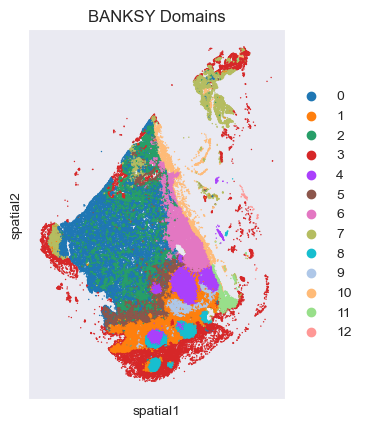

BANKSY complete for IHOPE14_MedLN_BottomLeft! Domains added to `adata.obs['banksy_domain']`


In [25]:
from banksy.main import median_dist_to_nearest_neighbour
from banksy.initialize_banksy import initialize_banksy
from banksy.embed_banksy import generate_banksy_matrix
from banksy_utils.umap_pca import pca_umap
from banksy.cluster_methods import run_Leiden_partition
from banksy.plot_banksy import plot_results

# Parameters for BANKSY
coord_keys = ('x', 'y', 'spatial')
k_geom = 15
max_m = 1
nbr_weight_decay = "scaled_gaussian"
lambda_list = [0.8]
resolutions = [0.5]       # Leiden clustering resolution
pca_dims = [20]             # Try a lower number?
cluster_algorithm = 'leiden'
cmap = 'tab20'             # color map for spatial plotting
save_path = None           # e.g., "./BANKSY_results" if you want to save figures

# Compute neighbor distances
nbrs = median_dist_to_nearest_neighbour(adata, key=coord_keys[2])

# Initialize BANKSY
banksy_dict = initialize_banksy(
    adata,
    coord_keys,
    k_geom,
    nbr_weight_decay=nbr_weight_decay,
    max_m=max_m,
    plt_edge_hist=False,
    plt_nbr_weights=True,
    plt_agf_angles=False,
    plt_theta=False
)

# Generate BANKSY matrix
banksy_dict, banksy_matrix = generate_banksy_matrix(
    adata,
    banksy_dict,
    lambda_list,
    max_m
)

# Dimensionality reduction by UMAP
pca_umap(
    banksy_dict,
    pca_dims=pca_dims,
    add_umap=True
)

# Run Leiden clustering
results_df, max_num_labels = run_Leiden_partition(
    banksy_dict,
    resolutions=resolutions,
    num_nn=50,
    num_iterations=-1,
    partition_seed=1234,
    match_labels=True,
    max_labels=None
)

# Map clusters back to adata
cluster_labels = results_df.labels[results_df.index[0]].dense
adata.obs['banksy_domain'] = cluster_labels.astype(str)

# Optional: visualize
sc.pl.spatial(adata, color='banksy_domain', spot_size=30, title='BANKSY Domains')

# Optional: use BANKSY plotting function
if save_path is not None:
    os.makedirs(save_path, exist_ok=True)
    weights_graph = banksy_dict['scaled_gaussian']['weights'][1]
    plot_results(
        results_df[results_df['num_labels']==len(np.unique(cluster_labels))],
        weights_graph,
        cmap,
        match_labels=True,
        coord_keys=coord_keys,
        max_num_labels=max_num_labels,
        save_path=save_path,
        save_fig=True,
        save_fullfig=True,
        dataset_name='Sample',
        save_labels=True
    )

print(f"BANKSY complete for {basename}! Domains added to `adata.obs['banksy_domain']`")

Save anndata object with BANKSY domains

In [27]:
from scripts.anndata_helpers import load_and_build_anndata, save_h5ad

h5adpath = f"../data/processed/anndata/zscore/{basename}_filtered_zscore_banksy.h5ad"
save_h5ad(adata, h5adpath)

# Rule-based cell typing

Each cell type will correspond to a column in the AnnData object, with a boolean True/False for every cell type in every cell.

On the lineage ("type") level, the labels are exclusive.

On the intermediate and subtype levels, labels may overlap.

Set file name/path and basename if needed:

In [16]:
# Load AnnData
adata = sc.read_h5ad(
    "../data/processed/anndata/zscore/IHOPE14_MedLN_BottomLeft_filtered_zscore_GMM_IHOPE_celltypes.h5ad"
)
basename = "IHOPE14_MedLN_BottomLeft"
print(f"Base name: {basename}")

Base name: IHOPE14_MedLN_BottomLeft


If the AnnData already has cell types, remove them:

In [28]:
cols_to_drop = [
    c for c in adata.obs.columns
    if c.startswith(("type_", "intermediate_", "subtype_", "state_"))
]

adata.obs.drop(columns=cols_to_drop, inplace=True)

print(f"Removed {len(cols_to_drop)} old annotation columns")

Removed 26 old annotation columns


**Cell typing**

In [29]:
from scripts.celltype_rules_IHOPE import assign_cell_types_bool_IHOPE

adata = assign_cell_types_bool_IHOPE(adata)


[TYPE VALIDATION]
Counts of assignments per cell:
1    112174
Name: count, dtype: int64
TYPE assignment is strictly exclusive (each cell has exactly one type)
Total cells: 112174

Level — type:
  type_B: 2747 (2.4% of total)
  type_T: 22530 (20.1% of total)
  type_NK: 18 (0.0% of total)
  type_Myeloid: 7436 (6.6% of total)
  type_Stromal: 13131 (11.7% of total)
  type_Endothelial: 18341 (16.4% of total)
  type_unclassified: 47971 (42.8% of total)

Level — intermediate:
  intermediate_CD4_T: 11953 (10.7% of total)
  intermediate_CD8_T: 3865 (3.4% of total)
  intermediate_T_naive: 669 (0.6% of total)
  intermediate_T_memory: 10498 (9.4% of total)
  intermediate_B_naive: 113 (0.1% of total)
  intermediate_B_memory: 1081 (1.0% of total)

Level — subtype:
  subtype_B_naive: 113 (0.1% of total)
  subtype_B_follicular_memory: 221 (0.2% of total)
  subtype_B_extrafollicular_memory: 579 (0.5% of total)
  subtype_TN_CD4: 507 (0.5% of total)
  subtype_TN_CD8: 41 (0.0% of total)
  subtype_TCM_CD4

Save:

In [30]:
from scripts.anndata_helpers import save_h5ad

celltype_path = f"../data/processed/anndata/NEW/{basename}_zscore_banksy_celltypes.h5ad"

save_h5ad(adata, celltype_path)

# B cell follicle domain annotation

Annotate BANKSY domains, here as B-cell follicles. This analysis is based on B cell enrichment across domains, you can then manually select the domains that are likely to be B cell follicles. You can also choose to set a B cell percentage threshold for what is annotated as a follicle.

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


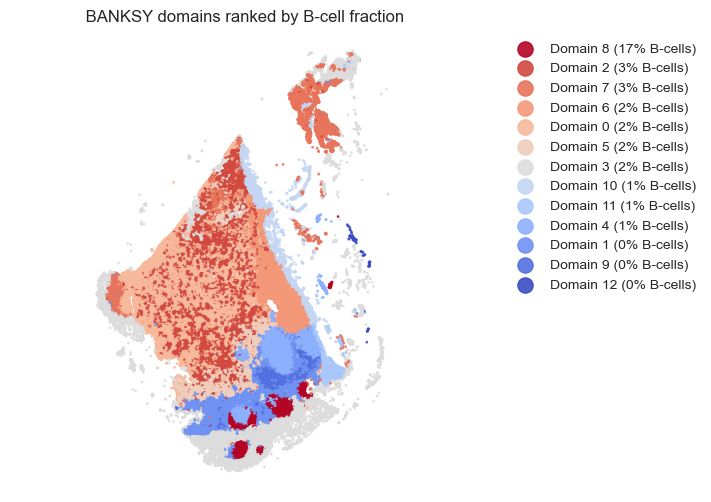

In [31]:
from scripts.banksy_domains import compute_domain_bcell_stats, plot_domains_by_bcell_fraction

stats_df = compute_domain_bcell_stats(adata)
plot_domains_by_bcell_fraction(adata, stats_df, cmap="coolwarm")

In [34]:
print(f"B_cell_percentage_spatial_{basename}_zscore_BANKSY")

B_cell_percentage_spatial_IHOPE14_MedLN_BottomLeft_zscore_BANKSY


Manually select top domains and add to anndata

In [35]:
top_domains = ['8']  # <-- you set this per sample, within ''

In [36]:
from scripts.banksy_domains import assign_bcell_follicles

adata = assign_bcell_follicles(
    adata,
    follicle_domains=top_domains,
    banksy_domain_key="banksy_domain",
    output_key="B_follicle",
)

print("Sanity check sum: ", adata.obs["B_follicle"].sum())

B_follicle: 6202 cells in 1 selected domains
Sanity check sum:  6202


Quick visual check of the follicle domain:

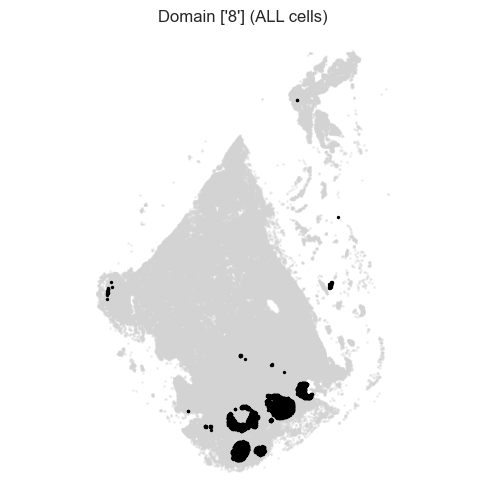

In [37]:
from scripts.banksy_domains import plot_domain_mask
plot_domain_mask(adata, top_domains)

Plot of the B cells within the selected domain


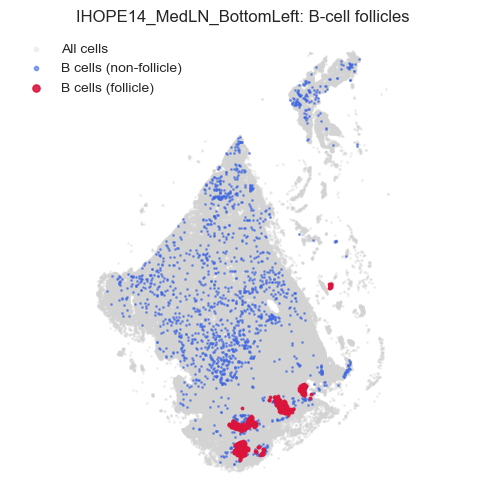

In [38]:
from scripts.banksy_domains import plot_bcell_follicles

plot_bcell_follicles(adata, sample_name = basename)

In [40]:
print(f"follicles_domain_{basename}_zscore_BANKSY")

follicles_domain_IHOPE14_MedLN_BottomLeft_zscore_BANKSY


Save:

In [41]:
follicle_path = f"../data/processed/anndata/NEW/{basename}_celltypes_follicledomains.h5ad"

save_h5ad(adata, follicle_path)

# Spatially informed cell typing
Finally, it's time to add the spatially defined cell types.

**TfH-like** inside follicles

In [42]:
from scripts.celltype_rules_IHOPE import add_TfH_like_cells

adata = add_TfH_like_cells(
    adata,
    follicle_key="B_follicle",
    plot=False,
    size=0.3,
    sample_name=basename
)

TfH-like cells: 2 (0.00% of all cells)


Follicular/extrafollicular memory B cells

In [ ]:
#GC-B AND PLASMABLASTS
from scripts.celltype_rules_IHOPE import add_spatial_B_context

adata = add_spatial_B_context(
    adata,
    follicle_key="B_follicle",
    plot=False,
    size=0.3,
    sample_name=basename
)

Save:

In [ ]:
final_path = f"../data/processed/anndata/NEW/{basename}_celltypes_follicledomains.h5ad"

save_h5ad(adata, final_path)

# Summarize

Generate a CSV file with cell type counts and percentages on all levels. This can be used in later analysis of the entire dataset.

In [ ]:
from scripts.summary_celltypes_IHOPE import summarize_celltypes_IHOPE

df_summary = summarize_celltypes_IHOPE(
    adata,
    filename=f"{basename}_filtered_zscore_summary.csv"
)

**Generate a summary of BANKSY domains**

This step applies a loop to all processed samples. Run after applying BANKSY and cell typing to all samples.

In [ ]:
from pathlib import Path
import scanpy as sc
import pandas as pd
import gc

ADATA_DIR = Path("../data/processed/anndata/NEW/debugged")

files = sorted(ADATA_DIR.glob("*_celltypes_follicledomains.h5ad"))

print(f"Found {len(files)} files:\n")

for f in files:
    print(f.name)

summary = []

for file in files:
    print(f"Processing {file.name}")

    adata = sc.read_h5ad(file)

    basename = file.stem.replace(
        "_celltypes_follicledomains", ""
    )

    total_domains = adata.obs["banksy_domain"].nunique()

    follicle_domains = len(
        adata.uns["B_follicle_domains"]
    )

    summary.append({
        "sample": basename,
        "total_banksy_domains": total_domains,
        "selected_follicle_domains": follicle_domains
    })

    del adata
    gc.collect()

Save summary in CSV format:

In [ ]:
summary_df = pd.DataFrame(summary)
summary_df.to_csv(
    "../results/banksy_domain_summary.csv",
    index=False
)
summary_df